<div style="text-align:center; background-color:#4e4e4e; font-family:Trebuchet MS; color:white; padding:14px; border-radius:4px; font-size:34px; border-style:solid; border-color:darkgreen;">Heart Disease Prediction using Machine Learning</div>

# 0. **Problem Statement & Introduction** <a class="anchor" id="0"></a>

## Problem Statement
Heart disease is a major health problem. The objective of this project is to build a **binary classification model** that predicts whether a patient has heart disease or not using clinical attributes such as age, chest pain type, blood pressure, cholesterol, maximum heart rate and other medical features.

**Goal:** Predict heart disease from the given patient attributes.

**Target:**
- `0` = No heart disease
- `1` = Heart disease present



---
# 1. **Exploratory Data Analysis** <a class="anchor" id="1"></a>
---

In [2]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, roc_auc_score, RocCurveDisplay)

pd.set_option('display.max_columns', None)
print('Libraries imported successfully.')

Libraries imported successfully.


## 1.1 **Load Dataset**
The code below automatically searches Kaggle input folders first. If the notebook is run locally, keep `heart.csv` in the same folder as this notebook.

In [3]:
kaggle_files = glob.glob('/kaggle/input/**/heart.csv', recursive=True)
local_files = glob.glob('heart.csv')

if kaggle_files:
    data_path = kaggle_files[0]
elif local_files:
    data_path = local_files[0]
else:
    raise FileNotFoundError(
        "heart.csv was not found. On Kaggle, attach the 'data855/heart-disease' dataset. "
        "For local Jupyter, place heart.csv in the same folder as this notebook."
    )

data = pd.read_csv(data_path)
print('Loaded from:', data_path)
print('Shape of the dataset:', data.shape)
data.head()

Loaded from: heart.csv
Shape of the dataset: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print('Column names:')
print(list(data.columns))

print('\nData types:')
print(data.dtypes)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


## 1.2 **Data Dictionary**
Typical columns in this heart-disease dataset are:

1. `age` — age in years
2. `sex` — sex of patient
3. `cp` — chest pain type
4. `trestbps` — resting blood pressure
5. `chol` — serum cholesterol
6. `fbs` — fasting blood sugar indicator
7. `restecg` — resting ECG result
8. `thalach` — maximum heart rate achieved
9. `exang` — exercise induced angina
10. `oldpeak` — ST depression induced by exercise
11. `slope` — slope of peak exercise ST segment
12. `ca` — number of major vessels
13. `thal` — thalassemia-related result
14. Target column — commonly `target` or `goal` depending on the dataset version.

If the target is `goal` with values 0–4, this notebook converts it into a binary target: `0 = no disease`, `1 = disease present`.

## 1.3 **Basic Data Checking**

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
print('Missing values per column:')
print(data.isnull().sum())

print('\nDuplicate rows:', data.duplicated().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 1


In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 1.4 **Target Preparation**

In [8]:
# Detect target column robustly
if 'target' in data.columns:
    target_col = 'target'
elif 'goal' in data.columns:
    target_col = 'goal'
elif 'num' in data.columns:
    target_col = 'num'
else:
    target_col = data.columns[-1]

print('Detected target column:', target_col)
print('Original target values:', sorted(data[target_col].dropna().unique().tolist()))

# Convert multi-class diagnosis 0-4 into binary classification if necessary
if data[target_col].nunique() > 2:
    data[target_col] = (data[target_col] > 0).astype(int)

# Make sure the target is integer 0/1 when possible
data[target_col] = data[target_col].astype(int)
print('Final target values:', sorted(data[target_col].unique().tolist()))

Detected target column: target
Original target values: [0, 1]
Final target values: [0, 1]


## 1.5 **Data Cleaning**

In [9]:
# Remove duplicate rows
data = data.drop_duplicates().copy()

# Replace common missing-value marker '?' with NaN and convert numeric-looking columns
data = data.replace('?', np.nan)
for col in data.columns:
    if col != target_col:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill numeric missing values using median
for col in data.columns:
    if col != target_col and data[col].isnull().any():
        data[col] = data[col].fillna(data[col].median())

print('Shape after cleaning:', data.shape)
print('Total missing values:', data.isnull().sum().sum())

Shape after cleaning: (302, 14)
Total missing values: 0


## 1.6 **Target Distribution**

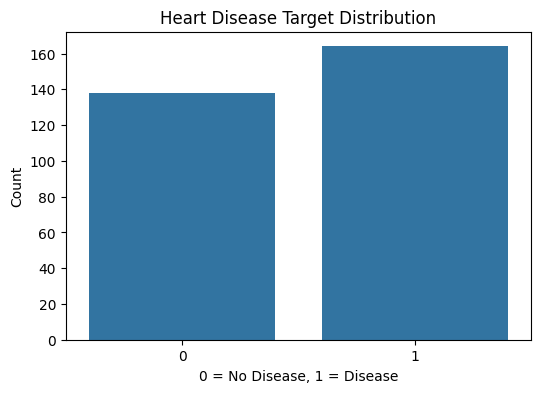

target
1    164
0    138
Name: count, dtype: int64

Percentage:
target
1    54.3
0    45.7
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=data)
plt.title('Heart Disease Target Distribution')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.show()

print(data[target_col].value_counts())
print('\nPercentage:')
print((data[target_col].value_counts(normalize=True)*100).round(2))

## 1.7 **Correlation Analysis**

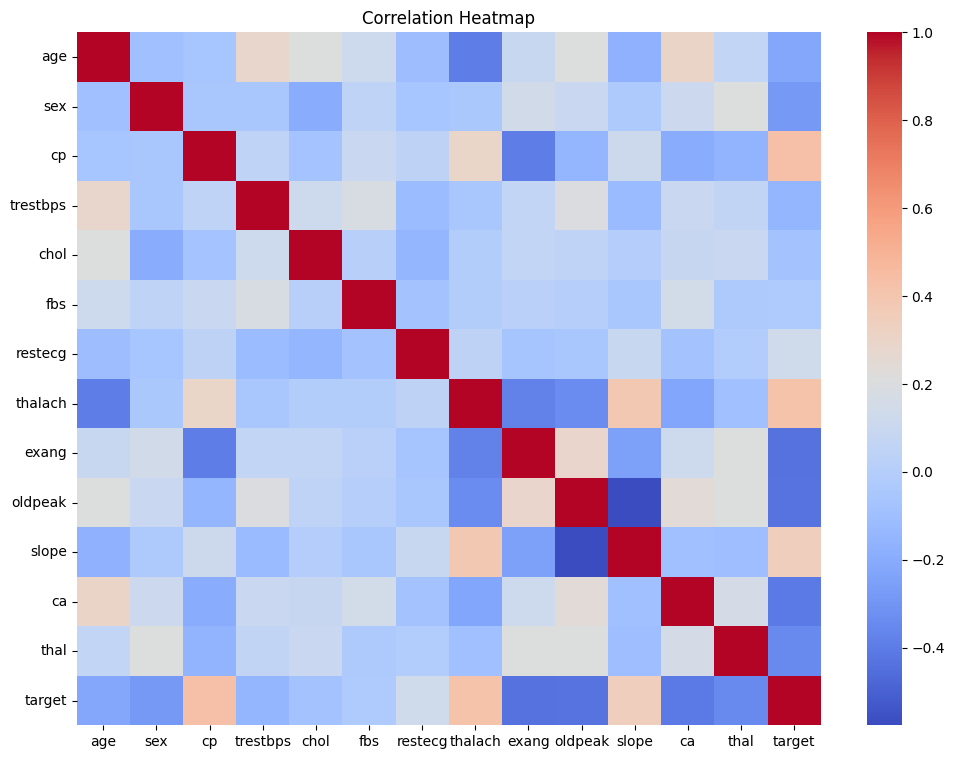

In [11]:
plt.figure(figsize=(12,9))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

---
# 2. **Machine Learning Modeling** <a class="anchor" id="2"></a>
---

## 2.1 **Feature and Target Separation**

In [12]:
X = data.drop(columns=[target_col])
y = data[target_col]

print('X shape:', X.shape)
print('y shape:', y.shape)
X.head()

X shape: (302, 13)
y shape: (302,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


## 2.2 **Train-Test Split**
We use 80% data for training and 20% for testing. `stratify=y` keeps the target-class ratio similar in both sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 241
Testing samples : 61


## 2.3 **Train Multiple Classification Models**
We compare three simple and commonly used classifiers:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Random Forest

In [14]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight='balanced'
    )
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    trained_models[name] = model

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1 Score': f1_score(y_test, pred, zero_division=0)
    }

    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_test)[:,1]
        row['ROC-AUC'] = roc_auc_score(y_test, prob)
    else:
        row['ROC-AUC'] = np.nan

    results.append(row)

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.8197,0.7750,0.9394,0.8493,0.8945
1,KNN,0.8033,0.7692,0.9091,0.8333,0.8674
2,Logistic Regression,0.7869,0.7632,0.8788,0.8169,0.8647


## 2.4 **Best Model Selection**
For a heart-disease classification problem, accuracy alone is not enough. Recall and F1-score are also important because missing a positive case can be costly. Here we select the model with the highest **F1-score**.

In [22]:
best_name = results_df.loc[0, 'Model']
best_model = trained_models[best_name]
best_pred = best_model.predict(X_test)

print('Best Model:', best_name)
print('\nClassification Report:\n')
print(classification_report(y_test, best_pred))

Best Model: Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



## 2.5 **Confusion Matrix**

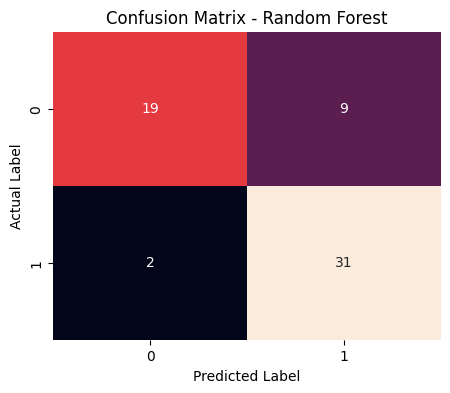

In [19]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cbar=False)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## 2.6 **ROC Curve**

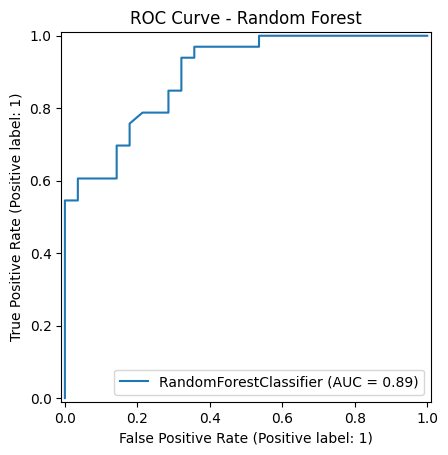

In [20]:
if hasattr(best_model, 'predict_proba'):
    RocCurveDisplay.from_estimator(best_model, X_test, y_test)
    plt.title(f'ROC Curve - {best_name}')
    plt.show()

## 2.7 **Feature Importance / Model Interpretation**

,Importance
cp,0.160099
thalach,0.116202
oldpeak,0.109217
thal,0.107692
ca,0.090314
chol,0.087440
age,0.082119
trestbps,0.076543
exang,0.061909
slope,0.046592


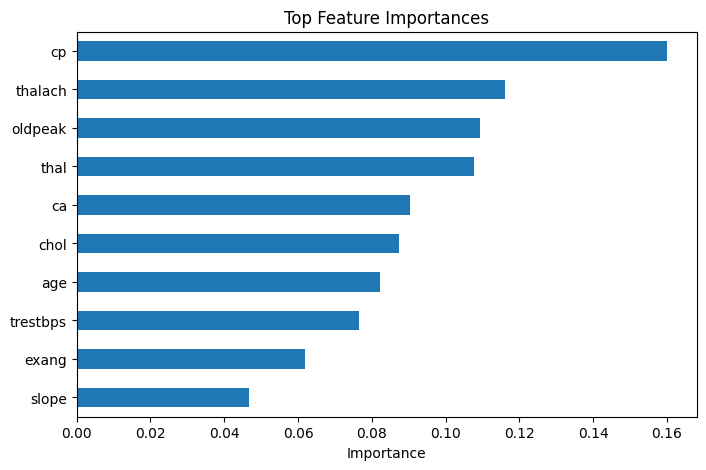

In [21]:
if best_name == 'Random Forest':
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    display(importances.to_frame('Importance'))
    plt.figure(figsize=(8,5))
    importances.head(10).sort_values().plot(kind='barh')
    plt.title('Top Feature Importances')
    plt.xlabel('Importance')
    plt.show()
elif best_name == 'Logistic Regression':
    coef = pd.Series(best_model.named_steps['model'].coef_[0], index=X.columns)
    coef = coef.reindex(coef.abs().sort_values(ascending=False).index)
    display(coef.to_frame('Coefficient').head(10))
else:
    print('KNN does not provide direct built-in feature importance.')

---
# 3. **Final Result & Conclusion** <a class="anchor" id="3"></a>
---

This notebook solved the heart-disease prediction problem as a supervised **binary classification** task. The main steps were:

1. Loaded and inspected the Kaggle heart-disease dataset.
2. Cleaned duplicate and missing values.
3. Converted the diagnosis target to binary form when required.
4. Performed exploratory analysis and correlation analysis.
5. Split the data into training and testing sets.
6. Trained Logistic Regression, KNN and Random Forest classifiers.
7. Compared the models using Accuracy, Precision, Recall, F1-score and ROC-AUC.
8. Selected the best model based on F1-score and displayed its confusion matrix and ROC curve.

**Problem solved:** The trained classifier can predict whether a patient is likely to have heart disease from the available clinical features.

> This project is for educational machine-learning practice and should not be treated as a medical diagnosis tool.

# 4. **Reference** <a class="anchor" id="4"></a>

- Kaggle Dataset: `data855/heart-disease`
- Scikit-learn documentation for classification models and evaluation metrics

## **End of Notebook!**

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color:#4e4e4e; padding:1em; margin:24px;">
<b>Heart Disease Prediction — Complete Machine Learning Solution</b>
</blockquote>